In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("/content/finance_economics_dataset.csv")
df

,Date,Stock Index,Open Price,Close Price,Daily High,Daily Low,Trading Volume,GDP Growth (%),Inflation Rate (%),Unemployment Rate (%),...,Forex USD/EUR,Forex USD/JPY,Crude Oil Price (USD per Barrel),Gold Price (USD per Ounce),Real Estate Index,Retail Sales (Billion USD),Bankruptcy Rate (%),Mergers & Acquisitions Deals,Venture Capital Funding (Billion USD),Consumer Spending (Billion USD)
0,01-01-2000,Dow Jones,2128.75,2138.48,2143.70,2100.55,2670411,-0.37,6.06,6.10,...,1.04,119.87,47.20,1052.34,390.23,2229,2.12,3,76.64,4589
1,02-01-2000,S&P 500,2046.82,2036.18,2082.83,2009.53,690220415,3.19,4.95,6.62,...,1.00,98.22,52.84,1957.73,346.23,4156,1.40,21,5.67,10101
2,03-01-2000,Dow Jones,1987.92,1985.26,2022.28,1978.37,315284661,5.54,9.13,2.60,...,0.83,80.13,78.80,2339.49,439.46,340,0.79,48,39.43,13665
3,04-01-2000,Dow Jones,4625.02,4660.47,4665.26,4595.46,13098297,10.00,3.77,2.20,...,0.95,149.15,28.18,1308.54,213.07,8456,4.22,16,12.83,5192
4,05-01-2000,S&P 500,1998.18,1982.18,2044.31,1966.44,385306746,1.53,2.20,8.20,...,1.43,113.71,92.20,2210.08,405.49,1596,2.21,34,86.37,10688
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,14-03-2008,Dow Jones,1273.76,1235.44,1317.28,1192.34,86910001,8.84,7.00,10.44,...,1.18,113.52,61.98,2385.41,298.72,3033,8.75,35,66.01,2200
2996,15-03-2008,S&P 500,4589.59,4566.91,4607.56,4545.69,303579301,-1.88,9.15,5.61,...,1.17,147.10,31.61,2147.13,143.43,7950,5.07,18,25.49,5261
2997,16-03-2008,S&P 500,1477.52,1448.47,1523.86,1402.69,442387176,4.07,0.88,8.91,...,1.02,81.99,45.64,1943.61,105.81,3894,5.78,4,14.29,12039
2998,17-03-2008,NASDAQ,2311.37,2306.90,2346.30,2282.00,523425925,1.06,8.61,10.15,...,1.49,86.42,123.25,2211.40,236.07,2543,2.35,22,94.34,11979


In [ ]:
# What is the shape of the dataset?
df.shape

(3000, 24)

In [ ]:
# What are the column names and their data types?
df.columns
df.dtypes

,0
Date,object
Stock Index,object
Open Price,float64
Close Price,float64
Daily High,float64
Daily Low,float64
Trading Volume,int64
GDP Growth (%),float64
Inflation Rate (%),float64
Unemployment Rate (%),float64


In [ ]:
# How many unique stock indices are there?
DF = df['Stock Index'].unique()
print(DF)

['Dow Jones' 'S&P 500' 'NASDAQ']


In [ ]:
#What is the date range of the dataset?
df1 = df['Date'].min()
df2 = df['Date'].max()
print(df1)
print(df2)


2000-01-01
2008-03-18


In [ ]:
# Are there any missing values?
print(df.isnull().sum())

Date                                     0
Stock Index                              0
Open Price                               0
Close Price                              0
Daily High                               0
Daily Low                                0
Trading Volume                           0
GDP Growth (%)                           0
Inflation Rate (%)                       0
Unemployment Rate (%)                    0
Interest Rate (%)                        0
Consumer Confidence Index                0
Government Debt (Billion USD)            0
Corporate Profits (Billion USD)          0
Forex USD/EUR                            0
Forex USD/JPY                            0
Crude Oil Price (USD per Barrel)         0
Gold Price (USD per Ounce)               0
Real Estate Index                        0
Retail Sales (Billion USD)               0
Bankruptcy Rate (%)                      0
Mergers & Acquisitions Deals             0
Venture Capital Funding (Billion USD)    0
Consumer Sp

In [ ]:
# Are there negative values in columns that should be non-negative?
cols = ['Open Price','Close Price','Daily High','Daily Low','Trading Volume',
        'Unemployment Rate (%)','Consumer Confidence Index',
        'Corporate Profits (Billion USD)','Forex USD/EUR','Forex USD/JPY',
        'Crude Oil Price (USD per Barrel)','Gold Price (USD per Ounce)',
        'Real Estate Index','Retail Sales (Billion USD)',
        'Bankruptcy Rate (%)','Venture Capital Funding (Billion USD)',
        'Consumer Spending (Billion USD)']

Negative = df[df[cols] < 0].any(axis=1)
print(Negative)

0       False
1       False
2       False
3       False
4       False
        ...  
2995    False
2996    False
2997    False
2998    False
2999    False
Length: 3000, dtype: bool


In [ ]:
df[Negative] ## there is no negative value in non-negative columns

,Date,Stock Index,Open Price,Close Price,Daily High,Daily Low,Trading Volume,GDP Growth (%),Inflation Rate (%),Unemployment Rate (%),...,Forex USD/EUR,Forex USD/JPY,Crude Oil Price (USD per Barrel),Gold Price (USD per Ounce),Real Estate Index,Retail Sales (Billion USD),Bankruptcy Rate (%),Mergers & Acquisitions Deals,Venture Capital Funding (Billion USD),Consumer Spending (Billion USD)


In [ ]:
#What is the summary of GDP Growth (%)?
df['GDP Growth (%)'].describe()

,GDP Growth (%)
count,3000.000000
mean,2.608903
std,4.287337
min,-5.000000
25%,-1.012500
50%,2.725000
75%,6.242500
max,10.000000


In [ ]:
# Are there rows with zero or near-zero trading volume?
df1 = (df['Trading Volume']==0 )| (df['Trading Volume']<1)
print(df1)


0       False
1       False
2       False
3       False
4       False
        ...  
2995    False
2996    False
2997    False
2998    False
2999    False
Name: Trading Volume, Length: 3000, dtype: bool


In [ ]:
df[df1] ## chcek for is there any true value? but this is empty

,Date,Stock Index,Open Price,Close Price,Daily High,Daily Low,Trading Volume,GDP Growth (%),Inflation Rate (%),Unemployment Rate (%),...,Forex USD/EUR,Forex USD/JPY,Crude Oil Price (USD per Barrel),Gold Price (USD per Ounce),Real Estate Index,Retail Sales (Billion USD),Bankruptcy Rate (%),Mergers & Acquisitions Deals,Venture Capital Funding (Billion USD),Consumer Spending (Billion USD)


In [ ]:
# Are there any duplicate rows?
df2 = df.duplicated()
print(df2)

0       False
1       False
2       False
3       False
4       False
        ...  
2995    False
2996    False
2997    False
2998    False
2999    False
Length: 3000, dtype: bool


In [ ]:
df[df2]  ## this is also blank it means there is no duplicate value

,Date,Stock Index,Open Price,Close Price,Daily High,Daily Low,Trading Volume,GDP Growth (%),Inflation Rate (%),Unemployment Rate (%),...,Forex USD/EUR,Forex USD/JPY,Crude Oil Price (USD per Barrel),Gold Price (USD per Ounce),Real Estate Index,Retail Sales (Billion USD),Bankruptcy Rate (%),Mergers & Acquisitions Deals,Venture Capital Funding (Billion USD),Consumer Spending (Billion USD)


In [ ]:
# Are there outliers in GDP, Gold, or Oil prices?
df3 = df[['GDP Growth (%)','Gold Price (USD per Ounce)','Crude Oil Price (USD per Barrel)']]
print(df3)

      GDP Growth (%)  Gold Price (USD per Ounce)  \
0              -0.37                     1052.34   
1               3.19                     1957.73   
2               5.54                     2339.49   
3              10.00                     1308.54   
4               1.53                     2210.08   
...              ...                         ...   
2995            8.84                     2385.41   
2996           -1.88                     2147.13   
2997            4.07                     1943.61   
2998            1.06                     2211.40   
2999            6.61                     1225.09   

      Crude Oil Price (USD per Barrel)  
0                                47.20  
1                                52.84  
2                                78.80  
3                                28.18  
4                                92.20  
...                                ...  
2995                             61.98  
2996                             31.61  
2997  

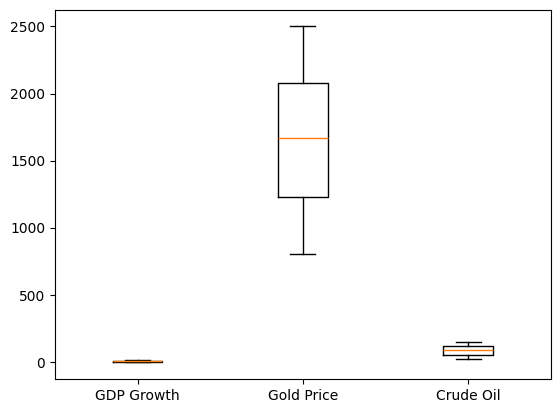

In [ ]:
plt.boxplot([
    df3['GDP Growth (%)'],
    df3['Gold Price (USD per Ounce)'],
    df3['Crude Oil Price (USD per Barrel)']
])

plt.xticks([1,2,3], ['GDP Growth', 'Gold Price', 'Crude Oil'])
plt.show() ## answer is , there is no outlier.

In [ ]:
# What is the summary of Inflation Rate (%)?
df['Inflation Rate (%)'].describe()

,Inflation Rate (%)
count,3000.000000
mean,5.096830
std,2.910513
min,0.010000
25%,2.607500
50%,5.110000
75%,7.600000
max,10.000000


In [ ]:
# What is the average unemployment rate?
df4 = df['Unemployment Rate (%)'].mean()
print(df4)

8.663786666666667


In [ ]:
# Which index has the highest trading volume?
df['Trading Volume'].max() ## for maximn value
df['Trading Volume'].idxmax() ## for index of maximum value

641

In [ ]:
# How many stock records are from each index?
df['Stock Index'].value_counts()

,count
Stock Index,
S&P 500,1036
NASDAQ,1007
Dow Jones,957


In [ ]:
# What is the correlation between inflation and interest rate?
DF1 = df['Inflation Rate (%)'].corr(df['Interest Rate (%)'])
print(DF1)

0.00573292723557624


In [ ]:
# What is the average Consumer Confidence Index?
DF2 = df['Consumer Confidence Index'].mean()
print(DF2)

85.036


In [ ]:
# Which column has the highest standard deviation?
DF3 = df[['Open Price','Close Price','Daily High','Daily Low','Trading Volume','GDP Growth (%)','Inflation Rate (%)','Unemployment Rate (%)','Interest Rate (%)','Consumer Confidence Index','Government Debt (Billion USD)','Corporate Profits (Billion USD)','Forex USD/EUR','Forex USD/JPY','Crude Oil Price (USD per Barrel)','Gold Price (USD per Ounce)','Real Estate Index','Retail Sales (Billion USD)','Bankruptcy Rate (%)','Mergers & Acquisitions Deals','Venture Capital Funding (Billion USD)','Consumer Spending (Billion USD)']].std().max()
print(DF3)

285900426.3714706


In [ ]:
DF3 = df[['Open Price','Close Price','Daily High','Daily Low','Trading Volume','GDP Growth (%)','Inflation Rate (%)','Unemployment Rate (%)','Interest Rate (%)','Consumer Confidence Index','Government Debt (Billion USD)','Corporate Profits (Billion USD)','Forex USD/EUR','Forex USD/JPY','Crude Oil Price (USD per Barrel)','Gold Price (USD per Ounce)','Real Estate Index','Retail Sales (Billion USD)','Bankruptcy Rate (%)','Mergers & Acquisitions Deals','Venture Capital Funding (Billion USD)','Consumer Spending (Billion USD)']].std().idxmax()
print(DF3)

Trading Volume


In [ ]:
# What is the highest gold price recorded?
goldvalue = df['Gold Price (USD per Ounce)'].max()
print(goldvalue)

2499.66


In [ ]:
# Which date had the highest crude oil price?
DATE = df.groupby('Date')['Crude Oil Price (USD per Barrel)'].max().idxmax()
print(DATE)

2001-11-22


In [ ]:
# What is the average corporate profit?
Ave_profit = df['Corporate Profits (Billion USD)'].mean()
print(Ave_profit)

2553.7563333333333


In [ ]:
# What percentage of the dataset shows negative GDP growth?
df1 = df['GDP Growth (%)']
n_GDP_Growth = df1[df['GDP Growth (%)'] < 0].count()
Percentage = (n_GDP_Growth / len(df)) * 100
print(n_GDP_Growth)
print("Percentage of the dataset shows negative GDP growth: ",Percentage)

947
Percentage of the dataset shows negative GDP growth:  31.566666666666666


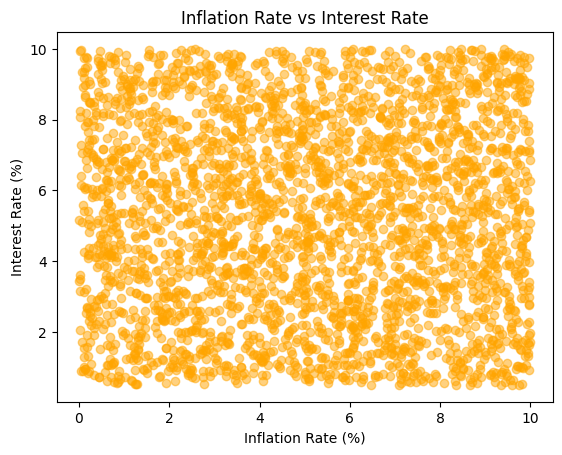

In [ ]:
# Does high inflation correspond to higher interest rates?
plt.scatter(df['Inflation Rate (%)'], df['Interest Rate (%)'], color='Orange',alpha =0.5)
plt.title('Inflation Rate vs Interest Rate')
plt.xlabel('Inflation Rate (%)')
plt.ylabel('Interest Rate (%)')
plt.show()

In [ ]:
corre = df['Inflation Rate (%)'].corr(df['Interest Rate (%)'])
print(corre)
## from this we can say there is no coreelation betweem inflation and interest.

0.00573292723557624


In [ ]:
# Is there a relationship between unemployment and consumer spending?
df5 = df['Unemployment Rate (%)'].corr(df['Consumer Spending (Billion USD)'])
print(df5)
#No there is no relationship between unemployment and consumer spending.

0.018786001938759088


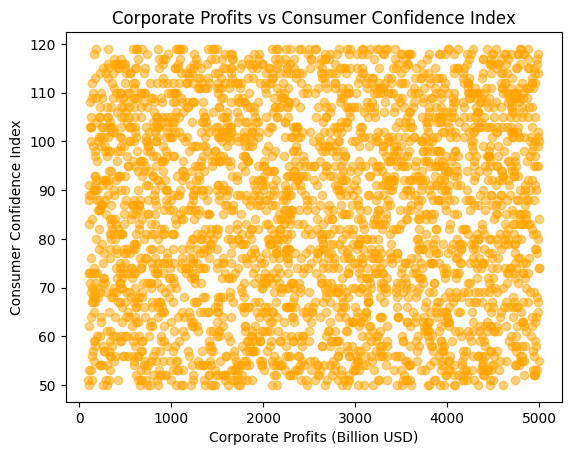

In [ ]:
# Do higher corporate profits align with higher consumer confidence?
plt.scatter(df['Corporate Profits (Billion USD)'], df['Consumer Confidence Index'], color='Orange',alpha =0.5)
plt.title('Corporate Profits vs Consumer Confidence Index')
plt.xlabel('Corporate Profits (Billion USD)')
plt.ylabel('Consumer Confidence Index')
plt.show()

            Date  Crude Oil Price (USD per Barrel)
0     2000-01-01                             47.20
1     2000-01-02                             52.84
2     2000-01-03                             78.80
3     2000-01-04                             28.18
4     2000-01-05                             92.20
...          ...                               ...
2995  2008-03-14                             61.98
2996  2008-03-15                             31.61
2997  2008-03-16                             45.64
2998  2008-03-17                            123.25
2999  2008-03-18                            144.06

[3000 rows x 2 columns]


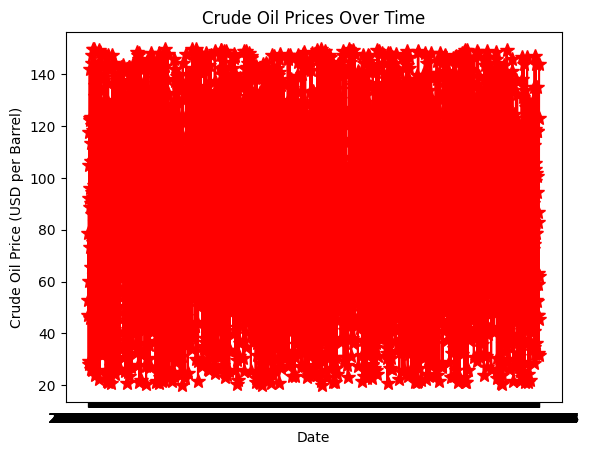

In [ ]:
# What’s the trend of crude oil prices over time?
df1 = df.groupby('Date')['Crude Oil Price (USD per Barrel)'].mean().reset_index()
print(df1)
plt.plot(df1['Date'], df1['Crude Oil Price (USD per Barrel)'], color='red',marker = '*', markersize=10)
plt.title('Crude Oil Prices Over Time')
plt.xlabel('Date')
plt.ylabel('Crude Oil Price (USD per Barrel)')
plt.show()

In [ ]:
#Are gold prices inversely related to stock performance?
Stock_perfo = (df['Close Price']-df['Open Price'])/df['Open Price']
print(Stock_perfo)
DF4 = df['Gold Price (USD per Ounce)'].corr(Stock_perfo)
print("Relation -", DF4)
## by the ans of correlation between gold prices and stock permonace are not related with eachother.

0       0.004571
1      -0.005198
2      -0.001338
3       0.007665
4      -0.008007
          ...   
2995   -0.030084
2996   -0.004942
2997   -0.019661
2998   -0.001934
2999    0.009580
Length: 3000, dtype: float64
Relation - -0.000378224892911753


<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

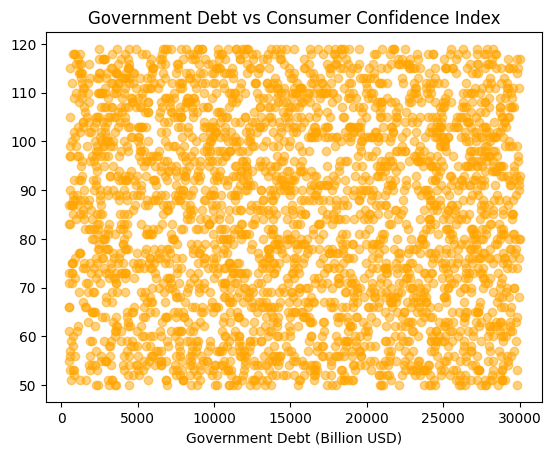

In [ ]:
# Does government debt impact consumer confidence?
plt.scatter(df['Government Debt (Billion USD)'], df['Consumer Confidence Index'], color='Orange',alpha =0.5)
plt.title('Government Debt vs Consumer Confidence Index')
plt.xlabel('Government Debt (Billion USD)')
plt
## here dots are random so there is no impact of goverment debt on consumer confidence.

Text(0, 0.5, 'Close Price')

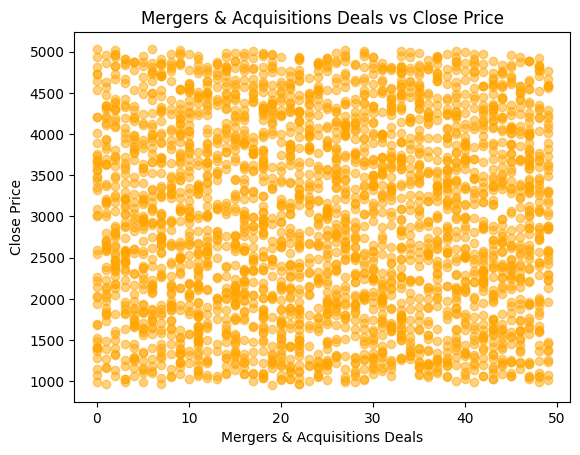

In [ ]:
# How do mergers & acquisitions (M&A) activity correlate with stock index closing prices?
plt.scatter(df['Mergers & Acquisitions Deals'], df['Close Price'], color='Orange',alpha =0.5)
plt.title('Mergers & Acquisitions Deals vs Close Price')
plt.xlabel('Mergers & Acquisitions Deals')
plt.ylabel('Close Price')
## from the graph and by calculation , we can say that M&A is not activity correlate with closing price.

In [ ]:
df6 = df['Mergers & Acquisitions Deals'].corr(df['Close Price'])
print(df6)

0.002637100789439038


In [ ]:
# Is retail sales growth associated with GDP growth?
df7 = df['Retail Sales (Billion USD)'].corr(df['GDP Growth (%)'])
print(df7)
# no retail sales growth is not associated with GDP growth.

-0.014287611445719916


0       0.004571
1      -0.005198
2      -0.001338
3       0.007665
4      -0.008007
          ...   
2995   -0.030084
2996   -0.004942
2997   -0.019661
2998   -0.001934
2999    0.009580
Length: 3000, dtype: float64


Text(0, 0.5, 'Consumer Spending (Billion USD)')

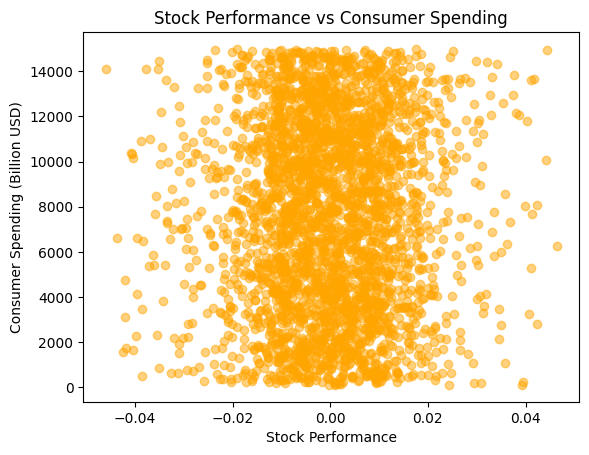

In [ ]:
# Is stock market performance linked to consumer spending?
Stock_perfo = (df['Close Price']-df['Open Price'])/df['Open Price']
print(Stock_perfo)
plt.scatter(Stock_perfo, df['Consumer Spending (Billion USD)'], color='Orange',alpha =0.5)
plt.title('Stock Performance vs Consumer Spending')
plt.xlabel('Stock Performance')
plt.ylabel('Consumer Spending (Billion USD)')
## by the graph and correlation, Stock market performance is not linked to consumer spending.

In [ ]:
df8 = Stock_perfo.corr(df['Consumer Spending (Billion USD)'])
print(df8)

0.013877715849959744


In [ ]:
# Which stock index had the highest average closing price?
high_avg_clo_price = df.groupby('Stock Index')['Close Price'].mean().idxmax()
print(high_avg_clo_price)

Dow Jones


In [ ]:
# What is the relationship between interest rate and unemployment?
df9 = df['Interest Rate (%)'].corr(df['Unemployment Rate (%)'])
print(df9)
## there is no relation between interest rate and umemployment

0.01800407213097277


In [ ]:
# Do lower consumer confidence values coincide with higher bankruptcy rates?
DF5 = df['Consumer Confidence Index'].corr(df['Bankruptcy Rate (%)'])
print(DF5)
## from the answer, Lower consumercofidence values is not coincide with higher bankruptcy rates.

-0.01631304347909408


In [ ]:
# Which indicator has the highest correlation with stock close price?
df1 = df[['Open Price','Close Price','Daily High','Daily Low','Trading Volume','GDP Growth (%)','Inflation Rate (%)','Unemployment Rate (%)','Interest Rate (%)','Consumer Confidence Index','Government Debt (Billion USD)','Corporate Profits (Billion USD)','Forex USD/EUR','Forex USD/JPY','Crude Oil Price (USD per Barrel)','Gold Price (USD per Ounce)','Real Estate Index','Retail Sales (Billion USD)','Bankruptcy Rate (%)','Mergers & Acquisitions Deals','Venture Capital Funding (Billion USD)','Consumer Spending (Billion USD)']]
DF6 = df1.corr()['Close Price'].sort_values(ascending=False)#.idxmax()
print(DF6)


Close Price                              1.000000
Daily High                               0.999821
Daily Low                                0.999820
Open Price                               0.999688
Retail Sales (Billion USD)               0.049370
Bankruptcy Rate (%)                      0.029380
Venture Capital Funding (Billion USD)    0.021414
Interest Rate (%)                        0.020434
Trading Volume                           0.016283
Consumer Confidence Index                0.013482
Corporate Profits (Billion USD)          0.008797
Mergers & Acquisitions Deals             0.002637
Crude Oil Price (USD per Barrel)         0.002563
Consumer Spending (Billion USD)          0.000376
Unemployment Rate (%)                   -0.001907
Government Debt (Billion USD)           -0.007332
Inflation Rate (%)                      -0.007972
Real Estate Index                       -0.008639
GDP Growth (%)                          -0.012748
Gold Price (USD per Ounce)              -0.014544


In [ ]:
# Are unemployment rates lower when corporate profits are high?
DF7 = df['Unemployment Rate (%)'].corr(df['Corporate Profits (Billion USD)'])
print(DF7)
## value is really near to zero , so there is no relation between unemployment rate and corporate profits.

0.008292414188235562


**Retail Sales Analysis**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
Data = pd.read_csv("/content/Retail Data.csv")
Data

,Order No,Order Date,Customer Name,Address,City,State,Customer Type,Account Manager,Order Priority,Product Name,...,Cost Price,Retail Price,Profit Margin,Order Quantity,Sub Total,Discount %,Discount $,Order Total,Shipping Cost,Total
0,4293-1,02-09-2014,Vivek Sundaresam,"152 Bunnerong Road,Eastgardens",Sydney,NSW,Small Business,Tina Carlton,Critical,UGen Ultra Professional Cordless Optical Suite,...,$156.50,$300.97,$144.47,23.0,"$4,533.52",2%,$194.83,"$4,757.22",$7.18,"$4,291.55"
1,5001-1,24-10-2015,Shahid Hopkins,"438 Victoria Avenue,Chatswood",Sydney,NSW,Corporate,Natasha Song,Medium,Bagged Rubber Bands,...,$0.24,$1.26,$1.02,8.0,$45.20,3%,$0.00,$45.90,$0.70,$46.91
2,5004-1,13-03-2014,Dennis Pardue,"412 Brunswick St,Fitzroy",Melbourne,VIC,Consumer,Connor Betts,Not Specified,TechSavi Cordless Navigator Duo,...,$42.11,$80.98,$38.87,45.0,$873.32,4%,$72.23,$837.57,$7.18,$82.58
3,5009-1,18-02-2013,Sean Wendt,"145 Ramsay St,Haberfield",Sydney,NSW,Small Business,Phoebe Gour,Critical,Artisan Printable Repositionable Plastic Tabs,...,$5.33,$8.60,$3.27,16.0,$73.52,1%,$4.35,$740.67,$6.19,$730.92
4,5010-1,13-09-2014,Christina Vanderzanden,"188 Pitt Street,Sydney",Sydney,NSW,Small Business,Tina Carlton,Not Specified,Pizazz Drawing Pencil Set,...,$1.53,$2.78,$1.25,49.0,$138.46,7%,$5.95,$123.77,$1.34,$125.97
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,6831-1,02-11-2016,Roland Murray,"438 Victoria Avenue,Chatswood",Sydney,NSW,Corporate,Natasha Song,Critical,Artisan Hi-Liter Smear-Safe Highlighters,...,$2.98,$5.84,$2.86,35.0,$115.40,2%,$10.81,$104.09,$0.83,$101.22
4996,6847-1,16-12-2015,Patrick OBrill,"63 Riley Street,Woolloomooloo",Sydney,NSW,Small Business,Tina Carlton,Not Specified,Smiths Colored Interoffice Envelopes,...,$19.83,$30.98,$11.15,49.0,"$1,999.69",7%,$143.91,"$1,947.75",$19.51,"$1,052.55"
4997,6922-1,28-09-2016,Troy Staebel,"1-2/299 Sussex St,Sydney",Sydney,NSW,Consumer,Aanya Zhang,Low,Laser DVD-RAM discs,...,$20.18,$35.41,$15.23,19.0,$929.40,9%,$27.88,$901.52,$1.99,$921.03
4998,6939-1,18-06-2016,Shaun Weien,"Shop 3/144 Wattle St,Ultimo",Sydney,NSW,Corporate,Samantha Chairs,Not Specified,Artisan 479 Labels,...,$1.59,$2.61,$1.02,23.0,$66.54,5%,$4.46,$63.77,$0.50,$64.27


In [ ]:
# Q-1 View the structure of the dataset (columns, types, missing values).
#Data.columns
#Data.dtypes
Data.isnull().sum()


,0
Order No,0
Order Date,0
Customer Name,0
Address,1
City,0
State,0
Customer Type,0
Account Manager,0
Order Priority,0
Product Name,0


In [ ]:
# Q-2 What is the shape (rows, columns) of the dataset?
Data.shape

(5000, 24)

In [ ]:
# Q-3 Are there any duplicate records?\
A3 = Data.duplicated().sum()
A3

np.int64(0)

In [ ]:
# Q-4 Are there any missing or corrupted entries in Ship Date, Order Date, or numeric columns?
A4 = Data[['Cost Price','Order No','Ship Date','Order Date','Cost Price','Retail Price','Profit Margin','Order Quantity','Sub Total','Discount %','Discount $','Order Total','Shipping Cost','Total']].isnull().sum()
A4

,0
Cost Price,0
Order No,0
Ship Date,0
Order Date,0
Cost Price,0
Retail Price,0
Profit Margin,0
Order Quantity,1
Sub Total,0
Discount %,0


In [4]:
# Q-5 Convert Order Date and Ship Date to datetime.
Data['Order Date'] = pd.to_datetime(Data['Order Date'],dayfirst = True)## according to your data structure #format = %d-%m-%y
Data['Ship Date'] = pd.to_datetime(Data['Ship Date'],dayfirst = True)
Data.dtypes


,0
Order No,object
Order Date,datetime64[ns]
Customer Name,object
Address,object
City,object
State,object
Customer Type,object
Account Manager,object
Order Priority,object
Product Name,object


In [ ]:
# Q-6 Check for future or inconsistent shipping dates.
from datetime import datetime
Today = datetime.today()
A61 = Data[(Data['Ship Date']) < (Data['Order Date'])]## shipping before order(inconsistent)
A62 = Data[(Data['Ship Date'])> Today] ## shipping after order(future)
print(A61)
#print(A62)


     Order No Order Date      Customer Name  \
12     5018-1 2013-12-29     Lena Creighton   
87     5042-1 2013-06-25         Karl Brown   
107    5055-1 2013-09-11     Liz Willingham   
149    5070-1 2014-10-29    Mike Gockenbach   
204    5106-1 2014-09-04        Cyma Kinney   
...       ...        ...                ...   
4685   6482-1 2016-11-09  Cassandra Brandow   
4710   6496-1 2015-08-31      Henny Holldon   
4881   6543-1 2015-09-17         Tony Sayre   
4959   6574-1 2017-01-30  Michelle Huthwait   
4972   6584-1 2015-08-24     Michael Oakman   

                                      Address       City State  \
12                    127 Liverpool St,Sydney     Sydney   NSW   
87                 470 Anzac Parade,Kingsford     Sydney   NSW   
107                  60 Commercial Rd,Prahran  Melbourne   VIC   
149                  224A Gertrude St,Fitzroy  Melbourne   VIC   
204   Sydney Fish Market, Bank Street, Sydney     Sydney   NSW   
...                                    

In [5]:
#Q-7 Convert price columns to numeric (remove $ and commas).
cols = ['Cost Price','Retail Price','Profit Margin','Sub Total','Discount %','Discount $','Shipping Cost','Total','Order Total']

for i in cols:
    Data[i] = (
        Data[i]
        .astype(str)                                  # ensure values are strings
        .str.replace('$', '', regex=False)
        .str.replace(',', '', regex=False)
        .str.replace('%', '', regex=False)  # remove $ and commas
    )
    Data[i] = pd.to_numeric(Data[i], errors='coerce')  # convert to numbers
Data

,Order No,Order Date,Customer Name,Address,City,State,Customer Type,Account Manager,Order Priority,Product Name,...,Cost Price,Retail Price,Profit Margin,Order Quantity,Sub Total,Discount %,Discount $,Order Total,Shipping Cost,Total
0,4293-1,2014-09-02,Vivek Sundaresam,"152 Bunnerong Road,Eastgardens",Sydney,NSW,Small Business,Tina Carlton,Critical,UGen Ultra Professional Cordless Optical Suite,...,156.50,300.97,144.47,23.0,4533.52,2,194.83,4757.22,7.18,4291.55
1,5001-1,2015-10-24,Shahid Hopkins,"438 Victoria Avenue,Chatswood",Sydney,NSW,Corporate,Natasha Song,Medium,Bagged Rubber Bands,...,0.24,1.26,1.02,8.0,45.20,3,0.00,45.90,0.70,46.91
2,5004-1,2014-03-13,Dennis Pardue,"412 Brunswick St,Fitzroy",Melbourne,VIC,Consumer,Connor Betts,Not Specified,TechSavi Cordless Navigator Duo,...,42.11,80.98,38.87,45.0,873.32,4,72.23,837.57,7.18,82.58
3,5009-1,2013-02-18,Sean Wendt,"145 Ramsay St,Haberfield",Sydney,NSW,Small Business,Phoebe Gour,Critical,Artisan Printable Repositionable Plastic Tabs,...,5.33,8.60,3.27,16.0,73.52,1,4.35,740.67,6.19,730.92
4,5010-1,2014-09-13,Christina Vanderzanden,"188 Pitt Street,Sydney",Sydney,NSW,Small Business,Tina Carlton,Not Specified,Pizazz Drawing Pencil Set,...,1.53,2.78,1.25,49.0,138.46,7,5.95,123.77,1.34,125.97
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,6831-1,2016-11-02,Roland Murray,"438 Victoria Avenue,Chatswood",Sydney,NSW,Corporate,Natasha Song,Critical,Artisan Hi-Liter Smear-Safe Highlighters,...,2.98,5.84,2.86,35.0,115.40,2,10.81,104.09,0.83,101.22
4996,6847-1,2015-12-16,Patrick OBrill,"63 Riley Street,Woolloomooloo",Sydney,NSW,Small Business,Tina Carlton,Not Specified,Smiths Colored Interoffice Envelopes,...,19.83,30.98,11.15,49.0,1999.69,7,143.91,1947.75,19.51,1052.55
4997,6922-1,2016-09-28,Troy Staebel,"1-2/299 Sussex St,Sydney",Sydney,NSW,Consumer,Aanya Zhang,Low,Laser DVD-RAM discs,...,20.18,35.41,15.23,19.0,929.40,9,27.88,901.52,1.99,921.03
4998,6939-1,2016-06-18,Shaun Weien,"Shop 3/144 Wattle St,Ultimo",Sydney,NSW,Corporate,Samantha Chairs,Not Specified,Artisan 479 Labels,...,1.59,2.61,1.02,23.0,66.54,5,4.46,63.77,0.50,64.27


In [ ]:
# Q-8 What are the unique values in Customer Type and Order Priority?
A8 = Data['Customer Type'].unique()
print(A8)
A81 = Data['Order Priority'].unique()
print(A81)

['Small Business' 'Corporate' 'Consumer' 'Home Office']
['Critical' 'Medium' 'Not Specified' 'Low' 'High']


In [ ]:
# Q-9 What are the most common shipping modes?
A9 = Data['Ship Mode'].value_counts().idxmax()
print(A9)

Regular Air


In [ ]:
# Q-10 Which cities have the highest number of orders?
A10 = Data.groupby('City')['Order Quantity'].sum().idxmax()
print(A10)

Sydney


In [ ]:
# Q-11 WWhat’s the range of order quantities and prices?
A11 = Data['Order Quantity'].min()
A111 = Data['Order Quantity'].max()
print(A11)
print(A111)
## range of order quantities
A112 = Data['Order Total'].min()
A113 = Data['Order Total'].max()
print(A112)
print(A113)
## range of order price

1.0
50.0
1.71
28299.51


In [11]:
# Q-12 Create a new column for shipping duration.
Data['Shipping Duration'] = Data['Ship Date'] - Data['Order Date']
Data

,Order No,Order Date,Customer Name,Address,City,State,Customer Type,Account Manager,Order Priority,Product Name,...,Retail Price,Profit Margin,Order Quantity,Sub Total,Discount %,Discount $,Order Total,Shipping Cost,Total,Shipping Duration
0,4293-1,2014-09-02,Vivek Sundaresam,"152 Bunnerong Road,Eastgardens",Sydney,NSW,Small Business,Tina Carlton,Critical,UGen Ultra Professional Cordless Optical Suite,...,300.97,144.47,23.0,4533.52,2,194.83,4757.22,7.18,4291.55,2 days
1,5001-1,2015-10-24,Shahid Hopkins,"438 Victoria Avenue,Chatswood",Sydney,NSW,Corporate,Natasha Song,Medium,Bagged Rubber Bands,...,1.26,1.02,8.0,45.20,3,0.00,45.90,0.70,46.91,2 days
2,5004-1,2014-03-13,Dennis Pardue,"412 Brunswick St,Fitzroy",Melbourne,VIC,Consumer,Connor Betts,Not Specified,TechSavi Cordless Navigator Duo,...,80.98,38.87,45.0,873.32,4,72.23,837.57,7.18,82.58,0 days
3,5009-1,2013-02-18,Sean Wendt,"145 Ramsay St,Haberfield",Sydney,NSW,Small Business,Phoebe Gour,Critical,Artisan Printable Repositionable Plastic Tabs,...,8.60,3.27,16.0,73.52,1,4.35,740.67,6.19,730.92,2 days
4,5010-1,2014-09-13,Christina Vanderzanden,"188 Pitt Street,Sydney",Sydney,NSW,Small Business,Tina Carlton,Not Specified,Pizazz Drawing Pencil Set,...,2.78,1.25,49.0,138.46,7,5.95,123.77,1.34,125.97,4 days
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,6831-1,2016-11-02,Roland Murray,"438 Victoria Avenue,Chatswood",Sydney,NSW,Corporate,Natasha Song,Critical,Artisan Hi-Liter Smear-Safe Highlighters,...,5.84,2.86,35.0,115.40,2,10.81,104.09,0.83,101.22,4 days
4996,6847-1,2015-12-16,Patrick OBrill,"63 Riley Street,Woolloomooloo",Sydney,NSW,Small Business,Tina Carlton,Not Specified,Smiths Colored Interoffice Envelopes,...,30.98,11.15,49.0,1999.69,7,143.91,1947.75,19.51,1052.55,2 days
4997,6922-1,2016-09-28,Troy Staebel,"1-2/299 Sussex St,Sydney",Sydney,NSW,Consumer,Aanya Zhang,Low,Laser DVD-RAM discs,...,35.41,15.23,19.0,929.40,9,27.88,901.52,1.99,921.03,2 days
4998,6939-1,2016-06-18,Shaun Weien,"Shop 3/144 Wattle St,Ultimo",Sydney,NSW,Corporate,Samantha Chairs,Not Specified,Artisan 479 Labels,...,2.61,1.02,23.0,66.54,5,4.46,63.77,0.50,64.27,2 days


In [ ]:
# Q-13 Are there any orders with zero or negative total or quantity?
A13 = Data[(Data['Order Quantity']<=0)|(Data['Order Total']<=0)]
print(A13)
# no there is none order/total with zero or negative.

Empty DataFrame
Columns: [Order No, Order Date, Customer Name, Address, City, State, Customer Type, Account Manager, Order Priority, Product Name, Product Category, Product Container, Ship Mode, Ship Date, Cost Price, Retail Price, Profit Margin, Order Quantity, Sub Total, Discount %, Discount $, Order Total, Shipping Cost, Total, Shipping Duration]
Index: []

[0 rows x 25 columns]


In [ ]:
# Q-14 Are all discount percentages matching discount dollar amounts?
Discount = (Data['Sub Total']*(Data['Discount %']/100))
if (Discount.round(2) == Data['Discount $'].round(2)).all() :
  print("All discount percentages matching discount dollar amounts")
else:
  print("Not all discount percentages matching discount dollar amounts")

Not all discount percentages matching discount dollar amounts


In [ ]:
# Q-15 Check for mismatches in total calculation.
Data['Calculation'] = (Data['Retail Price']*Data['Order Quantity'])-Data['Discount $']+Data['Shipping Cost']
mismatch = Data[Data['Calculation'].round(2) != Data['Total'].round(2)]
print(mismatch)

     Order No Order Date           Customer Name  \
0      4293-1 2014-09-02        Vivek Sundaresam   
1      5001-1 2015-10-24          Shahid Hopkins   
2      5004-1 2014-03-13           Dennis Pardue   
3      5009-1 2013-02-18              Sean Wendt   
4      5010-1 2014-09-13  Christina Vanderzanden   
...       ...        ...                     ...   
4995   6831-1 2016-11-02           Roland Murray   
4996   6847-1 2015-12-16          Patrick OBrill   
4997   6922-1 2016-09-28            Troy Staebel   
4998   6939-1 2016-06-18             Shaun Weien   
4999   6980-1 2015-08-12          Nora Pelletier   

                                  Address       City State   Customer Type  \
0          152 Bunnerong Road,Eastgardens     Sydney   NSW  Small Business   
1           438 Victoria Avenue,Chatswood     Sydney   NSW       Corporate   
2                412 Brunswick St,Fitzroy  Melbourne   VIC        Consumer   
3                145 Ramsay St,Haberfield     Sydney   NSW  Sma

In [ ]:
# Q-16 Identify top 5 products by order quantity.
A16 = Data.groupby('Product Name')['Order Quantity'].sum()#.nlarger(5) another function
A16 = A16.sort_values(ascending=False).head(5)
print(A16)

Product Name
Artisan 474 Labels                         3395.0
Smiths General Use 3-Ring Binders          3220.0
Artisan 479 Labels                         3039.0
Artisan 481 Labels                         2996.0
Apex Preferred Stainless Steel Scissors    2896.0
Name: Order Quantity, dtype: float64


In [ ]:
# Q -17 Which Account Manager handled the most revenue?
A17 = Data.groupby('Account Manager')['Total'].sum().idxmax()
print(A17)

Connor Betts


In [ ]:
# Q-18 What is the average shipping cost by mode?
A18 = Data.groupby('Ship Mode')['Shipping Cost'].mean()
print(A18)

Ship Mode
Delivery Truck    5.270085
Express Air       5.247311
Regular Air       5.503553
Name: Shipping Cost, dtype: float64


In [ ]:
# Q-19 , 20 Find the most profitable product.
A1920 = Data.groupby('Product Name')['Profit Margin'].sum().idxmax()
print(A1920)


Cando PC940 Copier


In [ ]:
#Q-1 What is the total revenue generated across all orders?
A1 = Data['Total'].sum().round(2)
print(A1)

3731536.4


In [ ]:
# Q-2 Which customer type generates more revenue?
A2 = Data.groupby('Customer Type')['Total'].sum().idxmax()
print(A2)

Corporate


In [6]:
# Q-3 How does order priority affect revenue?
A3 = Data.groupby('Order Priority')['Total'].agg(['mean', 'sum', 'count'])
print(A3)
## here when Order Priority is high at that moment average of revenue is low but order is high.
## here when order priority is Critical at that moment average of revenue is high but still order is low.

                      mean        sum  count
Order Priority                              
Critical        784.799966  694547.97    885
High            706.582740  794199.00   1124
Low             743.554170  640200.14    861
Medium          756.016021  784744.63   1038
Not Specified   748.941996  817844.66   1092


In [8]:
# Q-4 What is the average profit margin by product category?
A4 = Data.groupby('Product Category')['Profit Margin'].mean()
print(A4)

Product Category
Furniture          12.701953
Office Supplies    17.682609
Technology         20.423208
Name: Profit Margin, dtype: float64


In [10]:
#Q-5 What is the most profitable product overall?
A5 = Data.groupby('Product Name')['Profit Margin'].sum().idxmax()
print(A5)

Cando PC940 Copier


In [12]:
# Q -6 How many days does it usually take to ship an order?
A6 = Data['Shipping Duration'].mean()
print(A6)

1 days 20:03:15.840000


In [33]:
#Q-7 Do longer shipping times impact profit margins?
A7 = Data.groupby('Shipping Duration')['Profit Margin'].agg(['mean', 'sum'])
print(A7)
## if we are thorugh for average then it's not affect that much max mean is 222 and you can see 359 days shipping days are there.
## But overall profit sums, it might affect on orders and reputation.

                      mean     sum
Shipping Duration                 
-365 days            1.820    3.64
-364 days           12.895   25.79
-362 days            3.180    3.18
-359 days          222.000  222.00
-355 days            1.470    1.47
...                    ...     ...
306 days            19.810   19.81
316 days             1.020    1.02
338 days             1.250    1.25
366 days            13.900   27.80
370 days             0.980    1.96

[61 rows x 2 columns]


In [20]:
# Q-8 Which city brings in the highest revenue?
A8 = Data.groupby('City')['Total'].sum().idxmax()
print(A8)

Sydney


In [21]:
# Q-9 Which account manager generated the most revenue?
A9 = Data.groupby('Account Manager')['Total'].sum().idxmax()
print(A9)

Connor Betts


In [22]:
# Q-10 Which shipping mode is most cost-effective (lowest avg. shipping)?
A10 = Data.groupby('Ship Mode')['Shipping Cost'].mean().idxmin()
print(A10)

Express Air


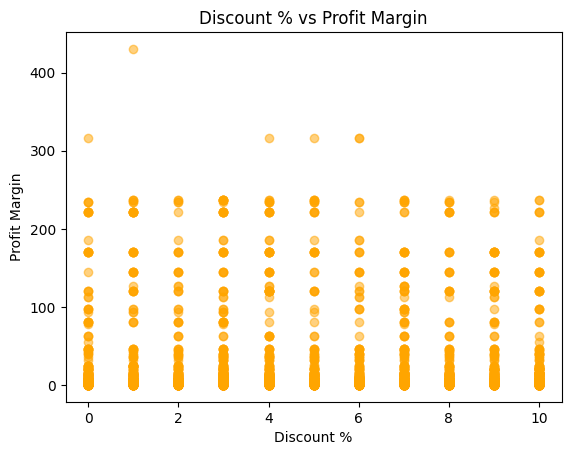

In [23]:
# Q-11 Do higher discounts reduce profits?
plt.scatter(Data['Discount %'], Data['Profit Margin'], color='Orange',alpha =0.5)
plt.title('Discount % vs Profit Margin')
plt.xlabel('Discount %')
plt.ylabel('Profit Margin')
plt.show()
## No, From graph we can see , if Discount is 2% or 10% then Profit Margin is same.

In [27]:
# Q-12 Which state has the highest number of orders?
A12 = Data.groupby('State')['Order Quantity'].sum().idxmax()
print(A12)

NSW


In [28]:
# Q-13 What is the average discount % across all orders?
A13 = Data['Discount %'].mean()
print(A13)

5.0338


In [29]:
# Q-14 What is the average total spend per order?
A14 = Data['Total'].mean()
print(A14)

746.3072800000001


In [30]:
# Q-15 Are certain containers (e.g., Small Box, Wrap Bag) more profitable?
Data['Profit'] = Data['Retail Price'] - Data['Cost Price']
A15 = Data.groupby('Product Container')['Profit'].sum().sort_values(ascending=False)
print(A15)

Product Container
Small Box     50560.40
Wrap Bag      24020.69
Small Pack     9612.16
Jumbo Drum     1928.56
Medium Box     1703.89
Large Box      1640.52
Name: Profit, dtype: float64
